# Notebook 17: Richards Equation — Transient Wetting Front

This notebook solves a **transient** Richards equation problem
and validates the numerical solution against an exact analytical
benchmark.  A wetting front propagates downward through an
initially dry soil column after a wet boundary condition is
applied at the top.

## Key Concepts

- Time-dependent Richards equation with the mixed form
- Gardner exponential model — linearisation trick
- Ogata–Banks advection–diffusion solution
- Wetting-front dynamics and mass conservation

## Why a Transient Benchmark?

[Notebook 16](16-Richards-Equation-Groundwater.ipynb) validated
the Richards solver at steady state, where the time derivative
vanishes and all formulations agree.  A transient test is needed
to verify that the **mixed form** storage term
$\partial\theta/\partial t$ is discretised correctly.

### The Gardner Linearisation

The substitution $u = \exp(\alpha\psi)$ transforms the nonlinear
Richards equation with Gardner conductivity into a **linear**
advection–diffusion equation:

$$\frac{\partial u}{\partial t}
  = D\,\frac{\partial^2 u}{\partial z^2}
  + V\,\frac{\partial u}{\partial z}$$

where $z = L - y$ is depth from the top,
$D = K_s / (\alpha\,\Delta\theta)$,
$V = K_s / \Delta\theta$, and
$\Delta\theta = \theta_s - \theta_r$.

### Ogata–Banks Solution

For a step change at the top ($z = 0$) from $u_{\rm dry}$ to
$u_{\rm wet}$ with a semi-infinite column, the
**Ogata–Banks (1961)** solution is:

$$u(z,t) = u_{\rm dry}
  + (u_{\rm wet} - u_{\rm dry})\,H(z,t)$$

where

$$H(z,t) = \tfrac{1}{2}\,\operatorname{erfc}\!\left(
    \frac{z - Vt}{2\sqrt{Dt}}\right)
  + \tfrac{1}{2}\,\exp\!\left(\frac{Vz}{D}\right)\,
    \operatorname{erfc}\!\left(\frac{z + Vt}{2\sqrt{Dt}}\right)$$

Converting back: $\psi(y,t) = \ln(u)/\alpha$.

The approximation is valid while the wetting front has not
yet reached the bottom boundary.

In [1]:
import numpy as np
import sympy
import underworld3 as uw
import matplotlib.pyplot as plt

from underworld3.utilities.retention_curves import (
    gardner_K,
    gardner_theta,
    gardner_transient_psi,
)

### Configurable parameters

Default values are defined as named constants below.  From the
command line, override them with PETSc-style flags:

```bash
python script.py -uw_res 64 -uw_alpha "4.0 1/m"
```

In [2]:
# --- Default values (edit these in a notebook) ---
COLUMN_HEIGHT = 3.0     # m   — tall column so the front stays away from the bottom
COLUMN_WIDTH  = 0.1     # m   — narrow (effectively 1-D)
RES           = 64      #     — vertical elements
KS            = 1.0     # m/s — saturated hydraulic conductivity (dimensionless-friendly)
ALPHA_G       = 4.0     # 1/m — Gardner sorptive number
THETA_R       = 0.05    #     — residual water content
THETA_S       = 0.40    #     — saturated water content
PSI_DRY       = -2.0    # m   — initial (dry) pressure head
PSI_WET       = -0.1    # m   — wet boundary at top
DT            = 0.005   # s   — timestep (accuracy is time-dominated)
SNAPSHOTS     = [0.05, 0.15, 0.30]  # s — times to compare

## Analytical Wetting Front

Before running the solver, let's visualise what the
analytical solution predicts at the snapshot times.

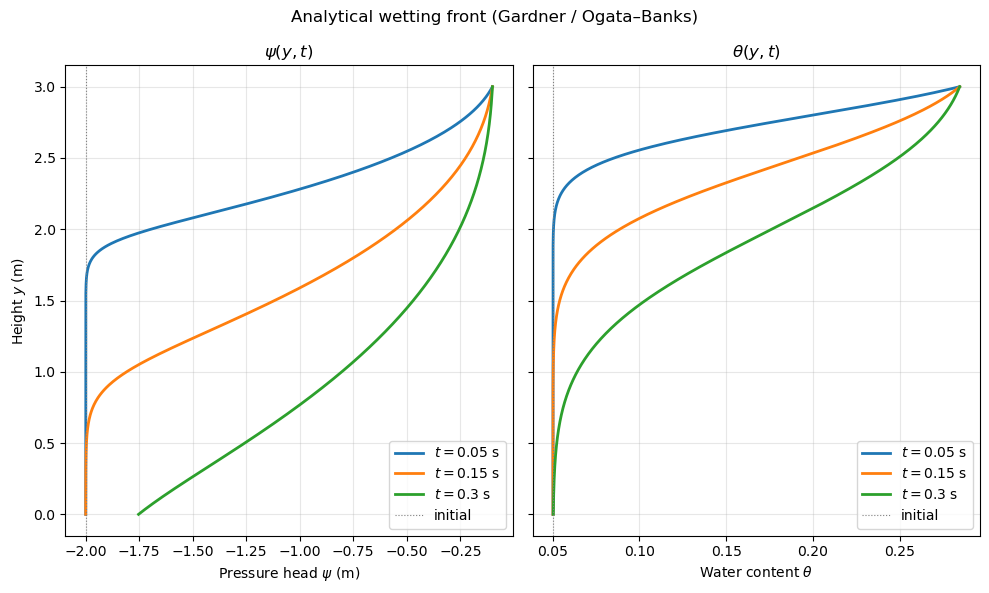

In [3]:
y_exact = np.linspace(0, COLUMN_HEIGHT, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

for t_snap in SNAPSHOTS:
    psi_exact = gardner_transient_psi(
        y_exact, t_snap,
        psi_dry=PSI_DRY, psi_wet=PSI_WET,
        L=COLUMN_HEIGHT, Ks=KS, alpha=ALPHA_G,
        theta_r=THETA_R, theta_s=THETA_S,
    )
    theta_exact = THETA_R + (THETA_S - THETA_R) * np.exp(ALPHA_G * np.clip(psi_exact, None, 0))

    ax1.plot(psi_exact, y_exact, lw=2, label=f"$t = {t_snap}$ s")
    ax2.plot(theta_exact, y_exact, lw=2, label=f"$t = {t_snap}$ s")

# Initial condition
ax1.axvline(PSI_DRY, color="grey", ls=":", lw=0.8, label="initial")
ax2.axvline(
    THETA_R + (THETA_S - THETA_R) * np.exp(ALPHA_G * PSI_DRY),
    color="grey", ls=":", lw=0.8, label="initial",
)

ax1.set_xlabel(r"Pressure head $\psi$ (m)")
ax1.set_ylabel("Height $y$ (m)")
ax1.set_title(r"$\psi(y, t)$")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel(r"Water content $\theta$")
ax2.set_title(r"$\theta(y, t)$")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle("Analytical wetting front (Gardner / Ogata–Banks)", fontsize=12)
fig.tight_layout()
plt.show()

## Set Up the Richards Solver

We create a vertical column mesh and configure the Richards
solver with Gardner constitutive curves.  The `water_content`
property activates the mixed (mass-conservative) form.

**Solver note:** The Gardner exponential creates steep
nonlinearity in dry regions where $K$ and $\theta$ are
very small.  The standard Newton method with backtracking
linesearch can overshoot into unphysical states.
A **trust-region** SNES (`newtontr`) constrains the
Newton step size and converges reliably.

In [4]:
mesh = uw.meshing.StructuredQuadBox(
    elementRes=(4, RES),
    minCoords=(0.0, 0.0),
    maxCoords=(COLUMN_WIDTH, COLUMN_HEIGHT),
    qdegree=3,
)

psi_var = uw.discretisation.MeshVariable(r"\psi", mesh, 1, degree=2)
v_soln  = uw.discretisation.MeshVariable("v", mesh, mesh.dim, degree=1)

Structured box element resolution 4 64


In [5]:
richards = uw.systems.Richards(mesh, psi_var, v_soln, order=1, theta=0.5, degree=3)
richards.petsc_options.delValue("ksp_monitor")
richards.petsc_options["snes_rtol"] = 1.0e-6
richards.petsc_options["snes_max_it"] = 50

# Trust-region Newton method — robust for the steep Gardner nonlinearity
richards.petsc_options["snes_type"] = "newtontr"

psi_sym = psi_var.sym[0]

# Constitutive model: Gardner K(ψ) with gravity
richards.constitutive_model = uw.constitutive_models.DarcyFlowModel
richards.constitutive_model.Parameters.permeability = gardner_K(
    psi_sym, Ks=KS, alpha=ALPHA_G
)
richards.constitutive_model.Parameters.s = sympy.Matrix([0, -1]).T

# Mixed form: θ(ψ) for mass-conservative storage
richards.water_content = gardner_theta(
    psi_sym,
    theta_r=THETA_R,
    theta_s=THETA_S,
    alpha=ALPHA_G,
)

richards.f = 0.0

# Boundary conditions
richards.add_dirichlet_bc([PSI_WET], "Top")
richards.add_dirichlet_bc([PSI_DRY], "Bottom")

# Velocity projector
richards._v_projector.petsc_options["snes_rtol"] = 1.0e-6
richards._v_projector.smoothing = 1.0e-3

## Initial Condition and Timestepping

We initialise with a smooth profile that interpolates between
the wet top and the dry interior (helps the first SNES iteration
converge). Then we step forward in time, saving snapshots at
the analytical comparison times.

In [6]:
# Initial condition: dry everywhere except a smooth transition
# near the top boundary to ease the first nonlinear solve.
y = mesh.X[1]
transition_width = 0.1 * COLUMN_HEIGHT
blend = sympy.Min(sympy.Max((COLUMN_HEIGHT - y) / transition_width, 0), 1)
psi_init = PSI_WET + (PSI_DRY - PSI_WET) * blend

psi_var.array = uw.function.evaluate(psi_init, psi_var.coords)

# IMPORTANT: the solver's time-derivative history was initialised at
# construction time (when psi_var was still zero).  Re-sync it now
# so that ψ^n = the initial condition we just set.
richards.DuDt.initiate_history_fn()

# Timestepping — collect snapshots
t_now = 0.0
snapshot_times = sorted(SNAPSHOTS)
snapshots = {}  # {t: psi_data}
next_snap_idx = 0

# Total time to run
t_end = snapshot_times[-1]
n_steps = int(np.ceil(t_end / DT))

for step in range(n_steps):
    richards.solve(timestep=DT)
    t_now += DT

    # Check if we've passed a snapshot time
    if next_snap_idx < len(snapshot_times) and t_now >= snapshot_times[next_snap_idx] - 1e-12:
        t_snap = snapshot_times[next_snap_idx]
        snapshots[t_snap] = np.array(psi_var.data)
        next_snap_idx += 1

print(f"Completed {n_steps} steps, t = {t_now:.4f} s")
print(f"Snapshots saved at t = {list(snapshots.keys())}")

[0]PETSC ERROR: --------------------- Error Message --------------------------------------------------------------
[0]PETSC ERROR: Object is in wrong state
[0]PETSC ERROR: Must call SNESSetFunction() or SNESSetDM() before SNESComputeFunction(), likely called from SNESSolve().
[0]PETSC ERROR: WARNING! There are unused option(s) set! Could be the program crashed before usage or a spelling mistake, etc!
[0]PETSC ERROR:   Option left: name:-dm_plex_hash_location (no value) source: code
[0]PETSC ERROR:   Option left: name:-options_left value: 0 source: code
[0]PETSC ERROR:   Option left: name:-Solver_5_mg_levels_ksp_converged_maxits (no value) source: code
[0]PETSC ERROR:   Option left: name:-Solver_5_mg_levels_ksp_max_it value: 3 source: code
[0]PETSC ERROR:   Option left: name:-Solver_5_pc_mg_type value: additive source: code
[0]PETSC ERROR:   Option left: name:-Solver_6_ksp_rtol value: 0.001 source: code
[0]PETSC ERROR:   Option left: name:-Solver_6_ksp_type value: gmres source: code
[0]

Error: error code 73

## Comparison with Analytical Solution

We sample each snapshot along a vertical profile and compare
with the Ogata–Banks solution.

In [ ]:
n_sample = 200
sample_y = np.linspace(0.05, COLUMN_HEIGHT - 0.05, n_sample)
sample_x = np.full_like(sample_y, COLUMN_WIDTH / 2)
sample_pts = np.column_stack([sample_x, sample_y])

fig, axes = plt.subplots(1, len(snapshots), figsize=(5 * len(snapshots), 6), sharey=True)
if len(snapshots) == 1:
    axes = [axes]

max_errors = []

for ax, (t_snap, psi_snap) in zip(axes, sorted(snapshots.items())):
    # Restore snapshot and evaluate
    psi_var.data[...] = psi_snap
    psi_numerical = uw.function.evaluate(psi_var.sym[0], sample_pts).squeeze()

    psi_analytical = gardner_transient_psi(
        sample_y, t_snap,
        psi_dry=PSI_DRY, psi_wet=PSI_WET,
        L=COLUMN_HEIGHT, Ks=KS, alpha=ALPHA_G,
        theta_r=THETA_R, theta_s=THETA_S,
    )

    error = np.abs(psi_numerical - psi_analytical)
    max_err = error.max()
    max_errors.append(max_err)

    ax.plot(psi_analytical, sample_y, "b-", lw=2, label="Analytical")
    ax.plot(psi_numerical, sample_y, "ro", ms=2, label="Numerical")
    ax.set_xlabel(r"$\psi$ (m)")
    ax.set_title(f"$t = {t_snap}$ s\nmax err = {max_err:.3e}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Height $y$ (m)")
fig.suptitle("Transient wetting front: numerical vs analytical", fontsize=12)
fig.tight_layout()
plt.show()

for t_snap, err in zip(sorted(snapshots.keys()), max_errors):
    print(f"  t = {t_snap:.2f} s : max |error| = {err:.4e} m")

## Darcy Velocity Field

The downward velocity should be highest at the wetting front
where the pressure gradient is steepest.

In [ ]:
# Use the final snapshot
t_final = sorted(snapshots.keys())[-1]
psi_var.data[...] = snapshots[t_final]
richards.solve(timestep=DT)  # recompute velocity

vy_numerical = uw.function.evaluate(v_soln.sym[0, 1], sample_pts).squeeze()

# Analytical Darcy velocity: q_y = K(ψ) (∂ψ/∂y + 1)
# Compute from the analytical ψ profile
psi_anal = gardner_transient_psi(
    sample_y, t_final,
    psi_dry=PSI_DRY, psi_wet=PSI_WET,
    L=COLUMN_HEIGHT, Ks=KS, alpha=ALPHA_G,
    theta_r=THETA_R, theta_s=THETA_S,
)
K_anal = KS * np.exp(ALPHA_G * np.clip(psi_anal, None, 0))
dpsi_dy = np.gradient(psi_anal, sample_y)
vy_analytical = K_anal * (dpsi_dy + 1)

fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(vy_analytical, sample_y, "b-", lw=2, label="Analytical")
ax.plot(vy_numerical, sample_y, "ro", ms=2, label="Numerical")
ax.set_xlabel(r"Vertical Darcy flux $q_y$ (m/s)")
ax.set_ylabel("Height $y$ (m)")
ax.set_title(f"Darcy velocity at $t = {t_final}$ s")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Try It Yourself

Experiment with different parameters to build intuition:

```python
# Larger α → sharper wetting front
ALPHA_G = 6.0

# Smaller timestep for better accuracy (error is time-dominated)
DT = 0.002

# Wetter initial condition
PSI_DRY = -1.0

# Higher resolution (spatial error is already small at RES=64)
RES = 128
```

- How does the front speed change with $\alpha$?
- What happens when the front reaches the bottom boundary?
  (The semi-infinite analytical solution breaks down.)
- Try computing total water content
  $\int_0^L \theta(\psi(y))\,dy$ at each snapshot to check
  mass conservation.

## References

Celia, M. A., Bouloutas, E. T. & Zarba, R. L. (1990). A general
mass-conservative numerical solution for the unsaturated flow equation.
*Water Resources Research*, 26(7), 1483–1496.
doi:[10.1029/WR026i007p01483](https://doi.org/10.1029/WR026i007p01483)

Gardner, W. R. (1958). Some steady-state solutions of the unsaturated
moisture flow equation with application to evaporation from a water table.
*Soil Science*, 85(4), 228–232.

Ogata, A. & Banks, R. B. (1961). A solution of the differential
equation of longitudinal dispersion in porous media.
*US Geological Survey Professional Paper* 411-A.

Richards, L. A. (1931). Capillary conduction of liquids through porous
mediums. *Physics*, 1(5), 318–333.
doi:[10.1063/1.1745010](https://doi.org/10.1063/1.1745010)